In [ ]:
# Fine tuning processing: Feature engineering ---> EDA
# Feature engineering: domain knowledge feature ---> string operations
# Domain knowledge feature: load base model ---> tokenization ---> create prompt and completion features
# EDA: univariate analysis ---> bivariate analysis 
# Imports
import os
import sys
from huggingface_hub import login
from tqdm import tqdm
# Add the utils folder to Python path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
pricer_path = os.path.join(notebook_dir, "../utils")
sys.path.insert(0, pricer_path)
# Class Item to validate the returned data and has lots of helper functions
from pricer.items import Item
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [2]:
# Login to Hugging Face
# Embed your Hugging Face token inside your .env and don't forget to load_dotenv(iverride=True)
hf_token = os.environ['HF_TOKEN']
# For login() it gonna be pormpt and we will put the token
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
# Download the batches dataset from Hugging Face 
username = "omarshaarawy11"
dataset = f"{username}/best_deal_03_batches"
train, val, test = Item.from_hub(dataset)
items = train + val + test
print(f"Loaded {len(items):,} items")

Loaded 21,091 items


In [4]:
# Invistigate the dataset
columns = ['title', 
'category', 
'price',
'full',
'weight',
'summary',
'prompt',
'id'
]
for i in columns:
    # Combine item with its attrs
    attr = getattr(items[0], i)
    print(attr)

Lurrose 100Pcs Full Cover Fake Toenails Artificial Transparent Nail Tips Nail Art for DIY
all beauty
6.99
None
0.0
Title: Lurrose 100pcs Full Cover Fake Toenails  
Category: Nail Art & Accessories  
Brand: Lurrose  
Description: High-quality, durable artificial toenails perfect for DIY nail art and manicures.  
Details: Features 100 lightweight, eco-friendly ABS nails that are easy to trim, shape, and fit comfortably to natural toenails, suitable for various styles and perfect as a gift.
None
None


In [ ]:
# Feature engineering
# Domain knowledge feature
# Load base model
BASE_MODEL = "meta-llama/Llama-3.2-3B"
# Tokenization object
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

In [7]:
# Invistigate tokens of summary
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

100%|██████████| 21091/21091 [00:31<00:00, 674.04it/s]


In [8]:
token_counts

[84,
 77,
 96,
 72,
 78,
 76,
 95,
 85,
 94,
 64,
 84,
 78,
 65,
 64,
 65,
 89,
 90,
 79,
 59,
 96,
 70,
 86,
 94,
 78,
 79,
 79,
 90,
 59,
 88,
 75,
 88,
 74,
 68,
 72,
 76,
 67,
 71,
 64,
 85,
 83,
 82,
 72,
 85,
 91,
 73,
 66,
 85,
 62,
 61,
 59,
 76,
 75,
 75,
 69,
 83,
 76,
 76,
 67,
 73,
 70,
 92,
 85,
 62,
 75,
 83,
 92,
 72,
 76,
 79,
 76,
 73,
 82,
 78,
 63,
 82,
 72,
 67,
 90,
 74,
 83,
 71,
 77,
 91,
 80,
 74,
 71,
 69,
 88,
 77,
 76,
 81,
 74,
 94,
 75,
 82,
 77,
 70,
 73,
 83,
 68,
 60,
 87,
 79,
 80,
 67,
 73,
 92,
 73,
 73,
 77,
 84,
 61,
 94,
 110,
 72,
 88,
 87,
 73,
 61,
 77,
 75,
 78,
 73,
 72,
 81,
 70,
 71,
 65,
 98,
 64,
 80,
 82,
 70,
 98,
 91,
 71,
 58,
 76,
 84,
 82,
 67,
 78,
 82,
 81,
 87,
 77,
 78,
 75,
 74,
 68,
 68,
 81,
 86,
 69,
 75,
 74,
 69,
 70,
 64,
 74,
 92,
 87,
 67,
 91,
 71,
 83,
 88,
 86,
 72,
 78,
 81,
 85,
 80,
 73,
 94,
 88,
 102,
 85,
 86,
 87,
 83,
 82,
 79,
 92,
 92,
 93,
 60,
 61,
 81,
 73,
 82,
 82,
 85,
 77,
 87,
 80,
 59,
 70,
 91,
 73

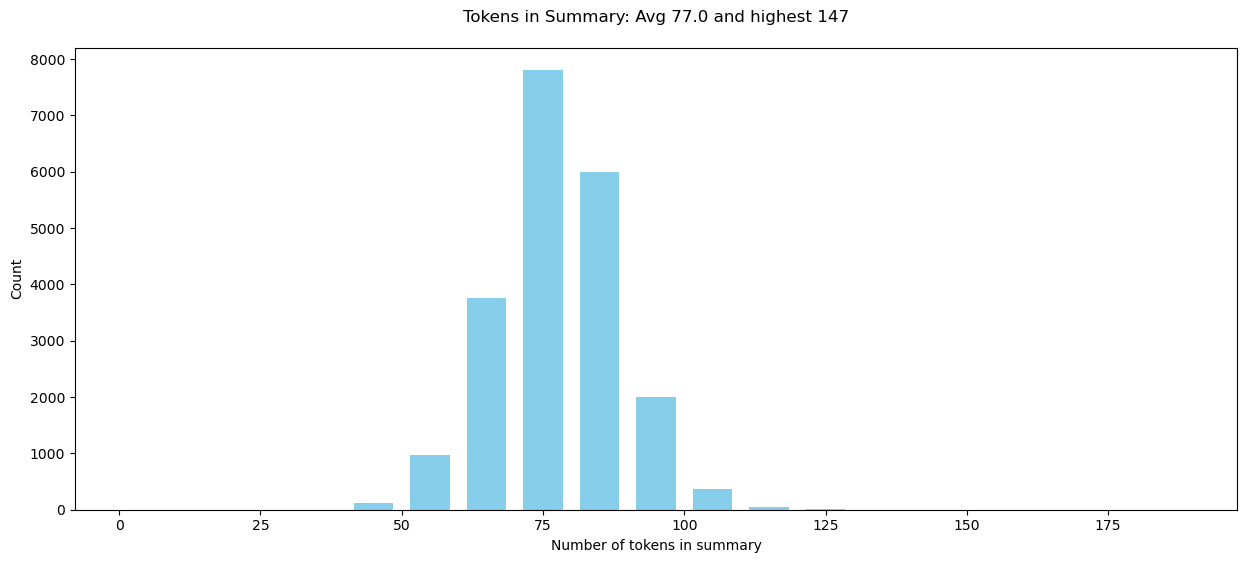

In [9]:
# EDA
# Univariete analysis
# Tokens of summary feature distribution
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

In [10]:
# String operations
# Truncate summary feature
# The max tokens we need is 90 tokens, truncate any text after this 
CUTOFF = 90
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")

With this CUTOFF, we will truncate 2,070 items which is 9.8%


In [13]:
# Tokenization ---> create pormpt and completion features
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

100%|██████████| 2191/2191 [00:02<00:00, 897.18it/s] 


In [14]:
# Input
print("PROMPT:")
print(test[0].prompt)
# Output
print("COMPLETION:")
print(test[0].completion)

PROMPT:
What does this cost to the nearest dollar?

Title: Vzaahu Silicone Ice Cube Trays with Lid - 2 Pack  
Category: Kitchen & Dining  
Brand: Vzaahu  
Description: Durable, flexible silicone ice cube trays with lids for easy release and odor prevention.  
Details: Features food-grade silicone, stackable design, removable spill-resistant lid, dishwasher safe, and customizable with fruits or flavors.

Price is $
COMPLETION:
8.99


In [15]:
# Invistigate tokens of full feature = prompt + completion
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

100%|██████████| 21091/21091 [00:05<00:00, 4137.17it/s]


In [16]:
prompt_token_counts

[99,
 92,
 106,
 87,
 93,
 91,
 105,
 100,
 106,
 79,
 99,
 93,
 80,
 79,
 80,
 104,
 105,
 94,
 74,
 106,
 85,
 101,
 106,
 93,
 94,
 94,
 105,
 74,
 103,
 90,
 103,
 89,
 83,
 87,
 91,
 82,
 86,
 79,
 100,
 98,
 97,
 87,
 100,
 106,
 88,
 81,
 100,
 77,
 76,
 74,
 91,
 90,
 90,
 84,
 98,
 91,
 91,
 82,
 88,
 85,
 106,
 100,
 77,
 90,
 98,
 106,
 87,
 91,
 94,
 91,
 88,
 97,
 93,
 78,
 97,
 87,
 82,
 105,
 89,
 98,
 86,
 92,
 106,
 95,
 89,
 86,
 84,
 103,
 92,
 91,
 96,
 89,
 106,
 90,
 97,
 92,
 85,
 88,
 98,
 83,
 75,
 102,
 94,
 95,
 82,
 88,
 106,
 88,
 88,
 92,
 99,
 76,
 106,
 106,
 87,
 103,
 102,
 88,
 76,
 92,
 90,
 93,
 88,
 87,
 96,
 85,
 86,
 80,
 106,
 79,
 95,
 97,
 85,
 106,
 106,
 86,
 73,
 91,
 99,
 97,
 82,
 93,
 97,
 96,
 102,
 92,
 93,
 90,
 89,
 83,
 83,
 96,
 101,
 84,
 90,
 89,
 84,
 85,
 79,
 89,
 106,
 102,
 82,
 106,
 86,
 98,
 103,
 101,
 87,
 93,
 96,
 100,
 95,
 88,
 106,
 103,
 106,
 100,
 101,
 102,
 98,
 97,
 94,
 106,
 106,
 106,
 75,
 76,
 96,
 88,
 

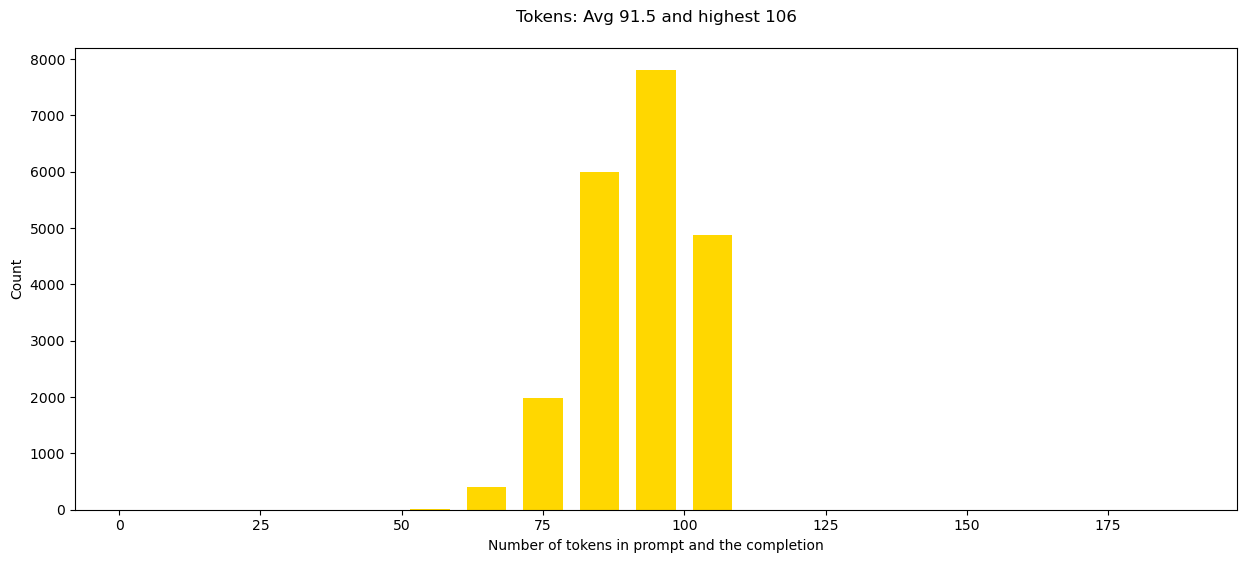

In [17]:
# EDA
# Univariete analysis
# Tokens of full feature distribution
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

In [19]:
# Push dataset to Hugging Face
import truststore
truststore.inject_into_ssl()
username = "omarshaarawy11"
items_data = f"{username}/best_deal_04_fine_tuning"
for item in items:
    item.full = None
    item.id = None
percentage = int(len(items) / 100)
train = items[:percentage * 80]
val = items[percentage * 80: percentage * 90]
test = items[percentage * 90: ]
Item.push_to_hub(items_data, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/17 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.
